# Глава 1.

### Пономарев Т. Е. 5130901/30201

## Упражнение 1.2

In [17]:
import sys 
import thinkdsp 
from thinkdsp import read_wave, decorate 

filename = "855185__looplicator__192-bpm-industrial-drum-loop-16567-wav.wav" 
# Промышленный барабанный луп № 16567 (WAV), 192 удара в минуту

wave = read_wave(filename) 
wave.make_audio()

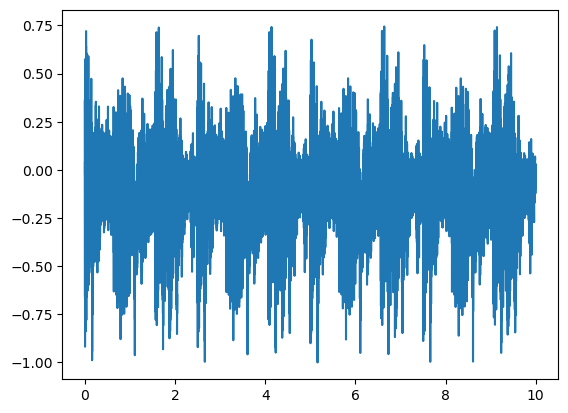

In [2]:
wave.plot()

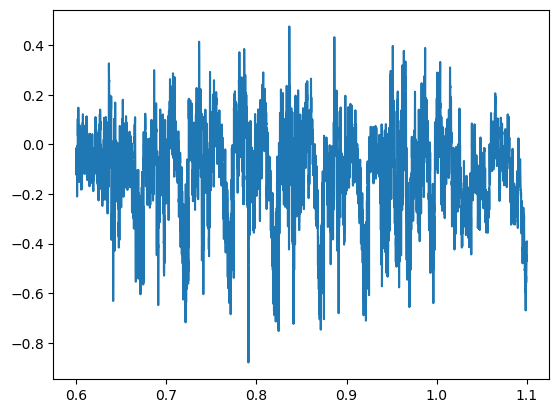

In [6]:
# Выделение сегмента
segment = wave.segment(0.6, 0.5)
segment.plot()

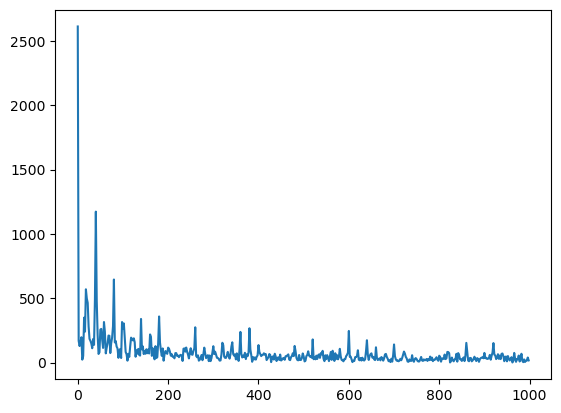

In [24]:
# Вычисление спектра
spectrum = segment.make_spectrum()
spectrum.plot(high = 1000)

In [10]:
spectrum.peaks()[:10]

[(np.float64(2611.500029108475), np.float64(0.0)),
 (np.float64(1173.0283606976175), np.float64(40.0)),
 (np.float64(645.7999787392736), np.float64(80.0)),
 (np.float64(569.7461066662443), np.float64(18.0)),
 (np.float64(498.61741066665223), np.float64(20.0)),
 (np.float64(491.3629747262094), np.float64(38.0)),
 (np.float64(477.0843613523103), np.float64(42.0)),
 (np.float64(464.6185081395191), np.float64(22.0)),
 (np.float64(358.60815920291606), np.float64(180.0)),
 (np.float64(349.4187784492164), np.float64(14.0))]

Как видно из спектра сегмента и списка пиков графика спектра основная и доминирующая частота - 40 герц. Воспринимаемая частота звука зависит от основной частоты 

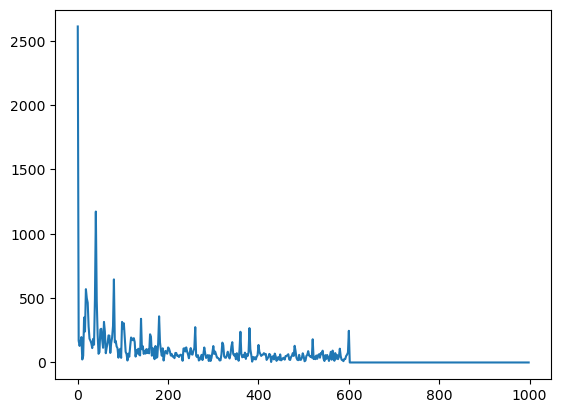

In [16]:
# Фильтрация гармоник (low)
spectrum.low_pass(600)
spectrum.plot(high=1000)

In [17]:
# Спектр в сигнал
low_filter = spectrum.make_wave()
low_filter.make_audio()

Звук стал ниже

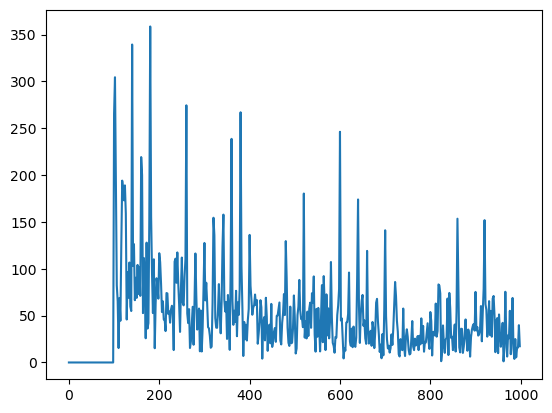

In [22]:
# Фильтрация гармоник (high)
spectrum.high_pass(100)
spectrum.plot(high=1000)

In [23]:
# Спектр в сигнал
low_filter = spectrum.make_wave()
low_filter.make_audio()

Звук стал заметно выше

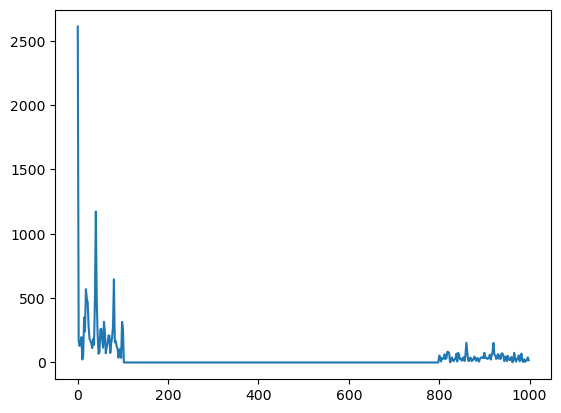

In [25]:
# Фильтрация гармоник (band_stop)
spectrum.band_stop(100, 800)
spectrum.plot(high=1000)

In [26]:
# Спектр в сигнал
low_filter = spectrum.make_wave()
low_filter.make_audio()

Звук стал плоским

## Упражнение 1.3

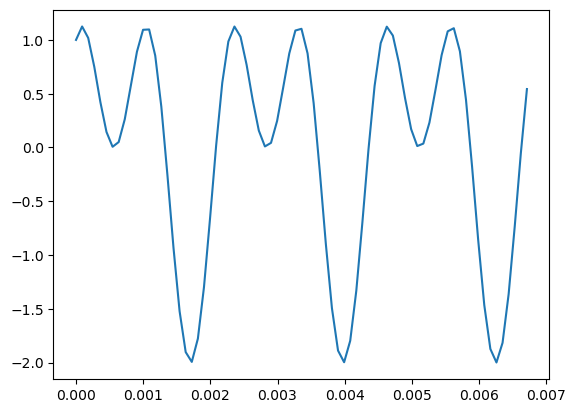

In [3]:
from thinkdsp import CosSignal, SinSignal

cos_sig = CosSignal(freq = 880)
sin_sig = SinSignal(freq = 440)

tog_sig = cos_sig + sin_sig
tog_sig.plot()

In [2]:
tog_sig_wave = tog_sig.make_wave()
tog_sig_wave.make_audio()

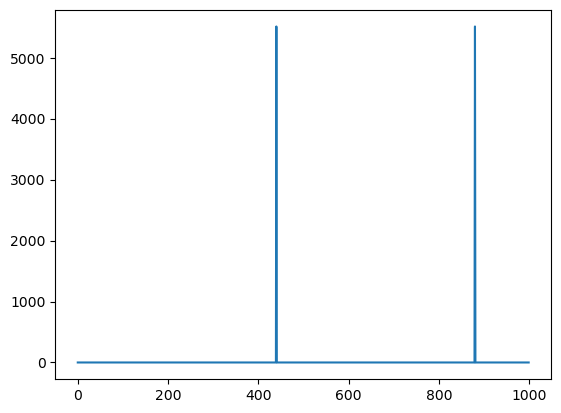

In [6]:
# Вычисление спектра составного сигнала 
tog_sig_spectrum = tog_sig_wave.make_spectrum()
tog_sig_spectrum.plot(high = 1000)

Что произойдет, если добавить частотные компоненты, которые не являются кратными основной частоте?

- сигнал перестанет быть периодичным и в спекте появятся новые пики.

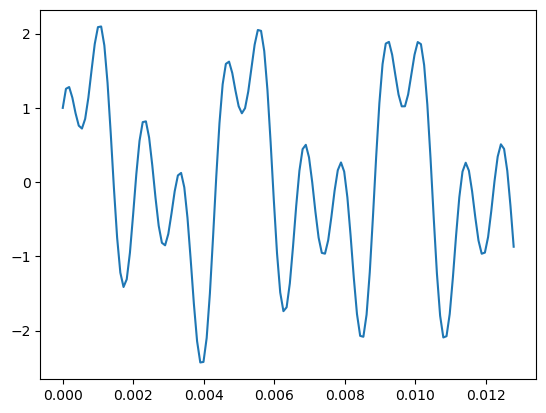

In [14]:
mix_tog_sig = tog_sig + SinSignal(freq = 233)
mix_tog_sig_wave = mix_tog_sig.make_wave()
mix_tog_sig.plot()

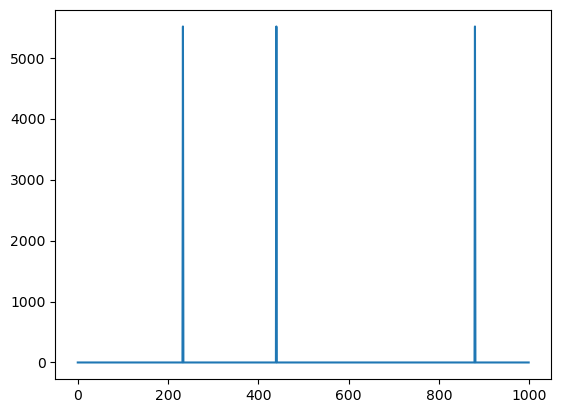

In [15]:
mix_tog_sig_spectrum = mix_tog_sig_wave.make_spectrum()
mix_tog_sig_spectrum.plot(high = 1000)

## Упражнение 1.4

Напишите функцию с именем stretch, которая принимает объект Wave и коэффициент растяжения и ускоряет или замедляет волну, изменяя значения ts и частоту кадров. Подсказка: на это должно уйти всего две строки кода.

In [19]:
def stretch(wave, coef):
    wave.ts *= coef
    wave.framerate /= coef
    return wave

wave.make_audio()

In [21]:
stretch(wave, 0.5).make_audio()

In [23]:
stretch(wave, 2).make_audio()